In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

# 数据集

In [2]:
words = open("names.txt", 'r').read().splitlines()
words[:8], len(words)

(['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia'],
 32033)

In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [4]:
# 老师的实现，更像个滚动窗口
block_size = 3  # context length: 预测下一个字符时所使用的上文长度
X,Y = [], []
for w in words[:5]:
    print(w)
    context = [0]*block_size  # context 用来存放当前上下文的变量
    for ch in w+'.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(f"{''.join(itos[i] for i in context)} ---> {ch}")
        context = context[1:] + [ix]  #上下文向右滑动一位 crop and append
X = torch.tensor(X)
Y= torch.tensor(Y)
print(X.shape, Y.shape, X.dtype, Y.dtype)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .
torch.Size([32, 3]) torch.Size([32]) torch.int64 torch.int64


In [5]:
# 构建用于MLP的数据集 这里输入变成3个字符 输出下一个字符 即：用前三个字符预测下一个字符

# 我的实现，其实结果是一样的，但是给人的含义不同
block_size = 3  # context length: 预测下一个字符时所使用的上文长度
X,Y = [], []
for w in words[:5]:
    print(w)
    context = ['.', '.', '.'] + list(w) + ['.']  
    # 这里这个block_size=3 其实就是输入的窗口长度，加上一个输出，其实整体的窗口长度是4，为了防止出现长度小于4的样本，这里直接对所有样本全部填充了...（这里的 . 字符其实是空白字符，占位用的）
    for i in range(len(context)-block_size):
        in_chs = context[i:i+block_size]
        out_ch = context[i+block_size]
        in_idx = [stoi[ch] for ch in in_chs]
        out_idx = stoi[out_ch]
        X.append(in_idx)
        Y.append(out_idx)
        print(f"{''.join(in_chs)} ---> {out_ch}")
X = torch.tensor(X)
Y= torch.tensor(Y)
print(X.shape, Y.shape)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .
torch.Size([32, 3]) torch.Size([32])


# 构建查找表(Embedding层)

原始论文是 1.7w个单词，嵌入到30维的空间里，即： 每个单词是一个30维的向量表示

这里因为全部的词表只有27个字符，因此简单点，先使用2维表示

注意，在之前的Bigram/单个线性层中，可以理解为：一个字符是由一个27维的向量表示的 

In [6]:
C = torch.randn((27,2))

In [7]:
C[5]

tensor([ 0.5751, -0.7419])

In [8]:
r = F.one_hot(torch.tensor([5]), num_classes=27).float()@C
r, r.shape

(tensor([[ 0.5751, -0.7419]]), torch.Size([1, 2]))

In [9]:
F.one_hot(torch.tensor([1]), num_classes=27).shape

torch.Size([1, 27])

这里要说明的问题就是:
+ 对于从嵌入矩阵中取出某个index的嵌入向量来说
+ 直接用序号索引, 或者直接用one-hot效果是一样的
+ 因为one-hot就是依据序号索引生成
+ 这里更多想说明:  矩阵乘法的作用

In [10]:
import numpy as np
index_num = np.random.randint(0, 27, 1000).tolist()

In [11]:
%time
r = F.one_hot(torch.tensor(index_num), num_classes=27).float()@C

CPU times: total: 0 ns
Wall time: 0 ns


In [12]:
%time
r = C[index_num,:]

CPU times: total: 0 ns
Wall time: 0 ns


`索引操作`比 `one-hot + 矩阵乘法`快得多，通常会快 10倍 到 50倍 以上。 `one-hot + 矩阵乘法`是深度学习中典型的“反模式”（做了大量无用功）。

如果采用这种方式, 也只是为了把这个操作变成一个`Wx`的乘法操作, 可以作为一个没有激活函数的线性层, 放到神经网络中, 

可以对`Wx`(也就是上面的`C`)进行反向传播, 来优化这个嵌入矩阵

In [13]:
X[1]

tensor([0, 0, 5])

In [14]:
C[X[1]]

tensor([[ 0.6589,  1.0283],
        [ 0.6589,  1.0283],
        [ 0.5751, -0.7419]])

In [15]:
C[X].shape, C.shape, X.shape

(torch.Size([32, 3, 2]), torch.Size([27, 2]), torch.Size([32, 3]))

这个索引就很牛逼了, 

C[X] (32, 3, 2) 就是查字典后的结果：把 `32x3` 个 `词ID`，全部替换成了对应的 2维词向量。

`C[X]` 这种语法糖，在底层等价于以下几种更明确的 PyTorch 操作：
```bash
# 等价于 F.embedding (最常用)
import torch.nn.functional as F
# 注意参数顺序：F.embedding(索引, 权重矩阵)
R = F.embedding(X, C) 

# 等价于 torch.index_select (更底层的实现)
# 先把 X 展平，去 C 里查，查完再恢复形状
R = torch.index_select(C, 0, X.flatten()).view(X.shape + C.shape[1:])
```

In [16]:
emb = C[X]

In [18]:
emb.shape

torch.Size([32, 3, 2])

# 构建隐藏层


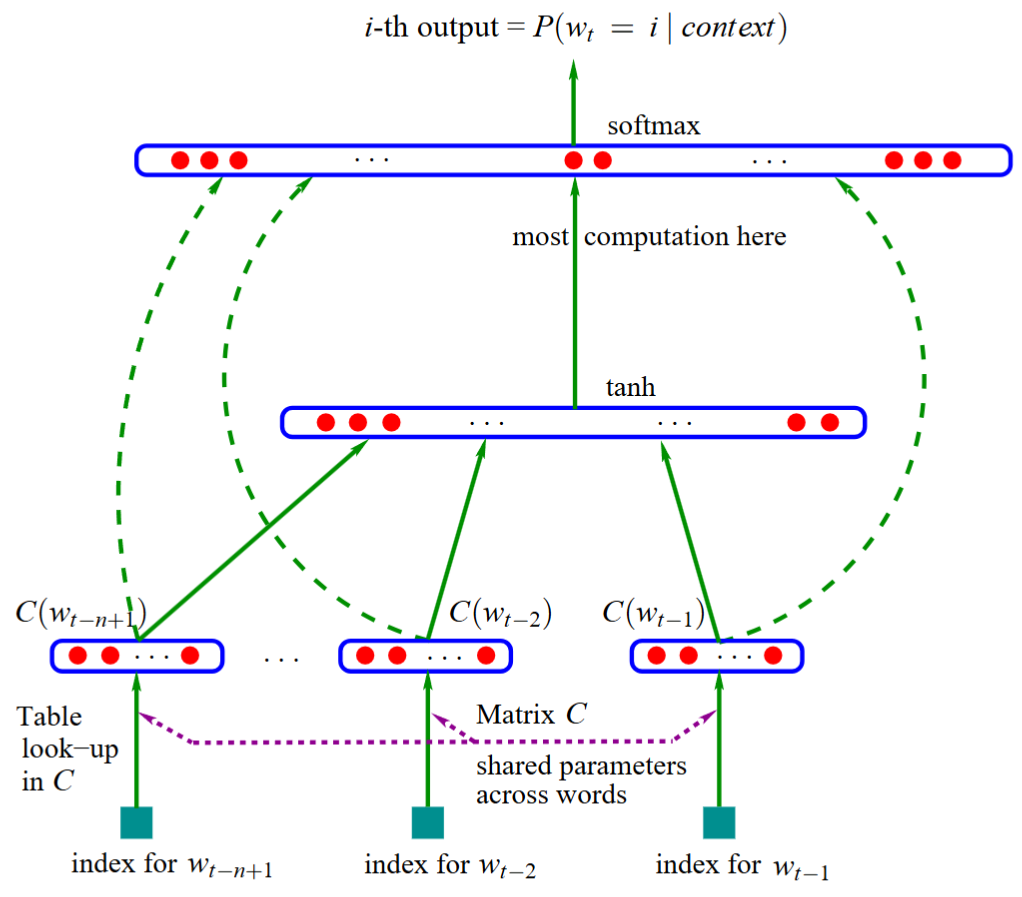

In [17]:
# 隐藏层的输入就是上面的 emb，就是 (32,3,2)维度 
# 但是实际上每次输入的其实是(3,2) 所以输入的神经元需要是6
# 输出的神经元这里暂时设置为100
# 同理，bias也需要是100
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [42]:
# 由于输入向量中的嵌入向量是堆叠在一起的，不是flatten 是个(3,2)的维度， 无法和W1的(6,100)直接相乘
# 因此，这里需要
# out = torch.cat((emb[:,0], emb[:,1], emb[:,2]), dim = 1)@W1 + b1
# out = torch.cat(torch.unbind(emb, dim = 1), dim = 1)@W1 + b1
# 更简单高效直接的写法
out = emb.view(32, emb.shape[1]*emb.shape[2])@ W1 + b1 
out.shape

torch.Size([32, 100])

[pytorch->Indexing, Slicing, Joining, Mutating Ops](https://docs.pytorch.org/docs/2.12/torch.html#indexing-slicing-joining-mutating-ops)

[Reference API -> torch -> torch.cat](https://docs.pytorch.org/docs/2.12/generated/torch.cat.html)

```bash
torch.cat((emb[:,0], emb[:,1], emb[:,2]), dim = 1)
# emb[:,0], emb[:,1], emb[:,2] 就相当于上面 C(wt-n+1) C(wt-2) C(wt-1) 提取这三个部分了
# 其实对应的就是 输入的32个三个字符中  32个第一个字符的2维嵌入   32个第二个字符的2维嵌入   32个第三个字符的2维嵌入 
```

In [29]:
# 但是使用这种写法不好泛化， 例如：当输入变成5个字符
r = torch.unbind(emb, dim = 1)
r[0].shape, len(r)

(torch.Size([32, 2]), 3)

[Reference API -> torch  -> torch.unbind](https://docs.pytorch.org/docs/2.12/generated/torch.unbind.html)

In [40]:
torch.cat(torch.unbind(emb, dim = 1), dim = 1) == emb.view(32, emb.shape[1]*emb.shape[2])
# 这种拼接操作会创建一个全新的变量，会分配新的内存空间
# 因为仅仅通过调整视图是无法实现张量拼接的
# 这种做法效率不高，同时还会占据存储空间

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

In [43]:
# h = emb.view(emb.shape[0], emb.shape[1]*emb.shape[2])@ W1 + b1 
h = emb.view(-1, 6)@ W1 + b1
# 只要其他维度确定，漏的那个-1的维度pytorch就会自己推导出来
h.shape

torch.Size([32, 100])

# 完整过程

In [89]:
# 构建映射字典
words = open("names.txt", 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

# 构建张量数据集
block_size = 3  # context length: 预测下一个字符时所使用的上文长度
X,Y = [], []
for w in words[:5]:
    # print(w)
    context = [0]*block_size  # context 用来存放当前上下文的变量
    for ch in w+'.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(f"{''.join(itos[i] for i in context)} ---> {ch}")
        context = context[1:] + [ix]  #上下文向右滑动一位 crop and append
X = torch.tensor(X)
Y= torch.tensor(Y)
print("X.shape: ", X.shape, "Y.shape: ", Y.shape)

# 构建嵌入矩阵
C = torch.randn((27,2))
emb = C[X]
print(f"emb.shape: {emb.shape}")

# 构建隐藏层
W1 = torch.randn((6, 100))
b1 = torch.randn(100)
h = torch.tanh(emb.view(-1, 6)@ W1 + b1)
print(h.shape)

W2 = torch.randn((100,27))
b2 = torch.randn(27)
logits = h@W2 + b2
print(logits.shape)

X.shape:  torch.Size([32, 3]) Y.shape:  torch.Size([32])
emb.shape: torch.Size([32, 3, 2])
torch.Size([32, 100])
torch.Size([32, 27])


In [57]:
# 计算softmax输出概率
counts = logits.exp()
prob = counts/counts.sum(dim=1, keepdim=True)
print(prob.shape, prob[1].sum())

torch.Size([32, 27]) tensor(1.0000)


In [58]:
# prob[torch.arange(prob.size()[0]), Y]
# 随机初始化计算出的概率很多都很垃圾

In [60]:
# 计算nll 负似然平均对数
loss = -prob[torch.arange(prob.size()[0]), Y].log().mean()
loss

tensor(19.8101)

# 开始优化（5个单词）

In [90]:
X.shape, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.Size([32]), torch.int64)

In [113]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator = g, requires_grad = True)
W1 = torch.randn((6, 100), generator = g, requires_grad = True)
b1 = torch.randn(100, generator = g, requires_grad = True)
W2 = torch.randn((100,27), generator = g, requires_grad = True)
b2 = torch.randn(27, generator = g, requires_grad = True)

parameters = [C, W1, b1, W2, b2]
# for p in parameters:
#     p.requires_grad = True

In [114]:
# sum(p.nelement() for p in parameters)
sum(p.numel() for p in parameters)
# https://docs.pytorch.org/docs/2.12/generated/torch.numel.html#torch.numel
# https://docs.pytorch.org/docs/2.12/generated/torch.Tensor.nelement.html

3481

In [115]:
lr = 0.1
for _ in range(1000):
    # 前向传播
    emb = C[X]
    h = torch.tanh(emb.view(-1,6)@W1 + b1)
    logits = h@W2 + b2
    
    # counts = logits.exp()
    # prob = counts/counts.sum(1,keepdim = True)
    # loss = - prob[torch.arange(32), Y].log().mean()
    # print(loss)
    # 两个loss算出来是相同的结果
    loss = F.cross_entropy(logits, Y)
    # print(loss.data)
    
    # 反向传播
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data-=lr*p.grad
print(loss.data)

tensor(0.2561)


只对5个人名(32个样本)进行了拟合，这里的损失是 0.2561， 相比于之前：
+ Bigram全部样本 nll=tensor(2.4544)
+ 单层 Wx拟合全部样本 tensor(2.4732)
+ 这里看起来数值确实很小

用3481个参数对 32个样本（相当于单个批次）进行拟合， 效果肯定是很ok的

现在还做不到损失为0，这是因为

In [116]:
logits.shape

torch.Size([32, 27])

In [117]:
logits.max(1)
# 查看logits32个样本中 27个维度的最大值，即 查看logits中每个样本最有可能的类别

torch.return_types.max(
values=tensor([13.3348, 17.7905, 20.6014, 20.6120, 16.7355, 13.3348, 15.9984, 14.1723,
        15.9146, 18.3614, 15.9396, 20.9265, 13.3348, 17.1090, 17.1319, 20.0601,
        13.3348, 16.5892, 15.1017, 17.0581, 18.5861, 15.9670, 10.8740, 10.6871,
        15.5056, 13.3348, 16.1794, 16.9743, 12.7426, 16.2008, 19.0845, 16.0195],
       grad_fn=<MaxBackward0>),
indices=tensor([19, 13, 13,  1,  0, 19, 12,  9, 22,  9,  1,  0, 19, 22,  1,  0, 19, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0]))

In [118]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [119]:
logits.max(1)[1] == Y  # 32个样本里只有4个不一样了

tensor([False,  True,  True,  True,  True, False,  True,  True,  True,  True,
         True,  True, False,  True,  True,  True, False,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True])

In [128]:
wrong_input = X[~(logits.max(1)[1] == Y)]
wrong_pred = Y[~(logits.max(1)[1] == Y)]
# print(wrong_input, wrong_pred)
for in_s, out_s in zip(wrong_input.data, wrong_pred.data):
    # print(in_s)
    in_chs = "".join([itos[i.item()] for i in in_s])
    out_chs = itos[out_s.item()]
    print(f"{in_chs} ---> {out_chs}")

... ---> e
... ---> o
... ---> a
... ---> i


这里可以看出：

预测失败的主要就是这个起始字符。。 `... -> s`最后一个单词的起始预测对了， 前面四个都被覆盖了，就错了

# 优化整个数据集

In [2]:
# 构建映射字典
words = open("names.txt", 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

# 构建张量数据集
block_size = 3  # context length: 预测下一个字符时所使用的上文长度
X,Y = [], []
for w in words:
    # print(w)
    context = [0]*block_size  # context 用来存放当前上下文的变量
    for ch in w+'.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(f"{''.join(itos[i] for i in context)} ---> {ch}")
        context = context[1:] + [ix]  #上下文向右滑动一位 crop and append
X = torch.tensor(X)
Y= torch.tensor(Y)
print("X.shape: ", X.shape, "Y.shape: ", Y.shape)

X.shape:  torch.Size([228146, 3]) Y.shape:  torch.Size([228146])


In [3]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator = g)
W1 = torch.randn((6, 100), generator = g)
b1 = torch.randn(100, generator = g)
W2 = torch.randn((100,27), generator = g)
b2 = torch.randn(27, generator = g)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [133]:
lr = 0.1
for _ in range(10):
    # 前向传播
    emb = C[X]
    h = torch.tanh(emb.view(-1,6)@W1 + b1)
    logits = h@W2 + b2
    loss = F.cross_entropy(logits, Y)
    print(loss.data)
    
    # 反向传播
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data-=lr*p.grad
# print(loss.data)

tensor(19.5052)
tensor(17.0845)
tensor(15.7765)
tensor(14.8333)
tensor(14.0026)
tensor(13.2533)
tensor(12.5799)
tensor(11.9831)
tensor(11.4705)
tensor(11.0519)


由于每次都是对 `X.shape:  torch.Size([228146, 3])` 整个22.8w个样本进行计算，所以每次计算都很慢，因此，这里需要处理一下这个问题

## 分批次处理

In [134]:
torch.randint(0, X.shape[0], (32,))
# 随机输出32个[0,228146)之间的数字

tensor([185334, 173964,   6442, 147962, 128743, 202830,  71376,  91994, 197371,
         48952, 153974,  25570,  11353, 224938, 148839, 161412, 108461, 162780,
         69774, 169849, 205145, 196114,  14062, 127081,  50067,    187,  92773,
        115672,   5857, 205026, 175806,  75858])

In [18]:
lr = 0.01
# 当训练效果趋于平缓时, 通常会选用学习率衰减的策略, 比如把lr从0.1变成0.01
for _ in range(10000):
    # mini batch
    ix = torch.randint(0, X.shape[0], (32,))
    # 前向传播
    emb = C[X[ix]]  # 只取32个采样的索引对应的X中的样本   mini-batch后，emb的维度就是(32,3,2), 而不是(228146,3,2)
    h = torch.tanh(emb.view(-1,6)@W1 + b1)
    logits = h@W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    # print(loss.data)
    
    # 反向传播
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data-=lr*p.grad
print(loss.data)

tensor(2.3201)


In [19]:
# 上面的小批次损失大概在 2.6~2.7之间波动
# 这里计算下整个数据集的loss
emb = C[X] 
h = torch.tanh(emb.view(-1,6)@W1 + b1)
logits = h@W2 + b2
loss = F.cross_entropy(logits, Y)
print(loss.data)

tensor(2.3198)


这里并不是基于所有2.28w样本来计算梯度，因此梯度指示的并不是真正的梯度方向，但是基于32个样本来估算梯度，梯度方向已经足够可靠，因此，可以采取这种方式来进行梯度更新
1. 精确计算梯度，减小步数(steps)
2. 近似计算梯度，增大步数(steps)

建议采用后者，效果会更好

另外，小批次的loss和整个数据集的loss，差距没有很多，最多就是差个0.2， 0.3

之前：
+ Bigram全部样本 nll=tensor(2.4544)
+ 单层 Wx拟合全部样本 tensor(2.4732)

这里损失已经是 `tensor(2.4067)`, 已经**超过了 Bigram 的结果**; 当训练效果趋于平缓时, 通常会选用学习率衰减的策略, 比如把lr从0.1变成0.01, 这之后,损失进一步降低到了 `tensor(2.3298)` 0.01的lr运行4w步, 可以得到`tensor(2.3198)`的损失

## 确定合适的学习率（步进速度）

逐个尝试查看损失变化情况， 从 10^1, 10^0, 10^(-1)..., 即 10, 1, 0.1, 0.01, 0.001, 0.0001 尝试这五个数值，看一下损失变化情况

找的变得很快和变得很慢的那个临界学习率， 这里尝试之后，合适的值应该在 1~0.001之间 

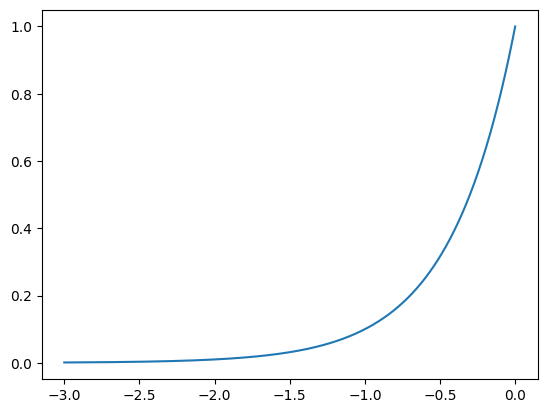

In [167]:
# lr = torch.linspace(0.001, 1,1000)  # 线性在 1和0.001之间生成1000个数字
# lr
# 但是这样好像不大对，所以考虑直接用指数来表达学习率变化(lr schedule)
lre = torch.linspace(-3, 0,1000)
# 指数是线性步进的，但是学习率是指数步进的
lrs = 10**lre
plt.plot(lre,lrs)

In [170]:
lrs[-1]/lrs[-2], lrs[-2]/lrs[-3], lrs[-3]/lrs[-4]

(tensor(1.0069), tensor(1.0069), tensor(1.0069))

In [171]:
lrs[-2]/lrs[-1], lrs[-3]/lrs[-2], lrs[-4]/lrs[-3]

(tensor(0.9931), tensor(0.9931), tensor(0.9931))

所以上面这个函数大概就等于 ExponentialLR 里 gamma = 1.0069

[Reference API -> torch.optim -> ExponentialLR](https://docs.pytorch.org/docs/2.12/generated/torch.optim.lr_scheduler.ExponentialLR.html)

但是注意，这个lrs并不是作为 lr schedule来使用的，而是作为lr候选搜索使用的，即:
+ 训练中lr并不会发生改变
+ 只是每次训练的全过程从lrs中选一个lr，找出最合适的lr

In [176]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator = g)
W1 = torch.randn((6, 100), generator = g)
b1 = torch.randn(100, generator = g)
W2 = torch.randn((100,27), generator = g)
b2 = torch.randn(27, generator = g)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

lri = []
lrei = []
lossi = []
lre = torch.linspace(-3, 0,1000)
lrs = 10**lre

for i in range(1000):
    ix = torch.randint(0, X.shape[0], (32,))
    emb = C[X[ix]]  
    h = torch.tanh(emb.view(-1,6)@W1 + b1)
    logits = h@W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    # print(loss.data)
    
    for p in parameters:
        p.grad = None
    loss.backward()
    lr = lrs[i]
    for p in parameters:
        p.data-=lr*p.grad

    # track stats
    lri.append(lr)
    lrei.append(lre[i]) # 本质上这里需要记录的是指数，而不是学习率
    lossi.append(loss.item())

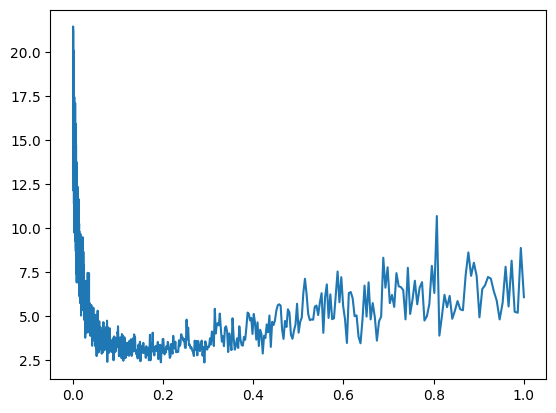

In [177]:
plt.plot(lri,lossi)

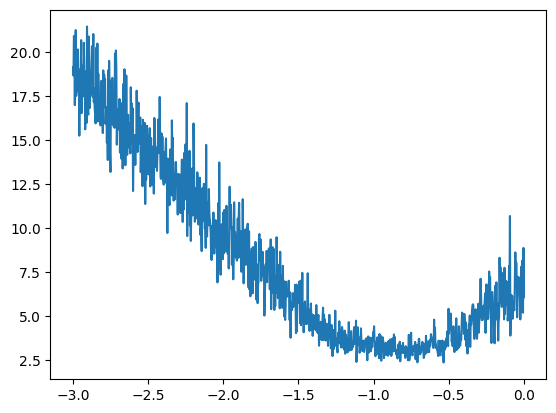

In [178]:
plt.plot(lrei,lossi)

由上图可知，lr的指数设置在-1.0左右比较好，也就是$10^{-1} = 0.1$左右的lr是比较合适的

In [179]:
10**(-1)

0.1

## 总结

整体的训练思路:
1. 手动试一下 lr = 10, 1, 0.1, 0.01以及0.001这几个值, 大概判断下损失变化情况. 找到变得很快和变得很慢的那个临界学习率. 例如:这里尝试之后，合适的值应该在 1~0.001之间
2. 直接用单个批量的损失结果看一下学习率曲线, 进一步确定比较好的lr范围
   ```python
       lre = torch.linspace(-3, 0,1000)
       lrs = 10**lre
   ```
3. 用上面确定的lr来运行训练, 当训练效果趋于平缓时, 通常会选用学习率衰减的策略, 比如把lr从0.1变成0.01


# 数据集划分(超参调整)

In [21]:
def build_datasets(words):
    block_size = 3  # context length: 预测下一个字符时所使用的上文长度
    X,Y = [], []
    for w in words:
        context = [0]*block_size  # context 用来存放当前上下文的变量
        for ch in w+'.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  #上下文向右滑动一位 crop and append
    X = torch.tensor(X)
    Y= torch.tensor(Y)
    print(X.shape, Y.shape, X.dtype, Y.dtype)
    return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_datasets(words[:n1])
Xdev, Ydev = build_datasets(words[n1:n2])
Xte, Yte = build_datasets(words[n2:])

torch.Size([182580, 3]) torch.Size([182580]) torch.int64 torch.int64
torch.Size([22767, 3]) torch.Size([22767]) torch.int64 torch.int64
torch.Size([22799, 3]) torch.Size([22799]) torch.int64 torch.int64


In [23]:
len(words), n1, n2-n1, len(words)-n2 # 每个划分集的words数, 不等于样本数

(32033, 25626, 3203, 3204)

In [74]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10), generator = g)
W1 = torch.randn((30, 200), generator = g)
b1 = torch.randn(200, generator = g)
W2 = torch.randn((200,27), generator = g)
b2 = torch.randn(27, generator = g)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [85]:
# 只在训练集上训练
lr = 0.01
lossi = []
stepi = []
for i in range(10000):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    # 前向传播
    emb = C[Xtr[ix]]  
    h = torch.tanh(emb.view(-1,30)@W1 + b1)
    logits = h@W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # 反向传播
    for p in parameters:
        p.grad = None
    loss.backward()
    for p in parameters:
        p.data-=lr*p.grad
    lossi.append(loss.log10().item()) # 加入log10()是为了让曲线更平滑,更容易看清楚趋势
    stepi.append(i)
print(loss.data)

tensor(2.0355)


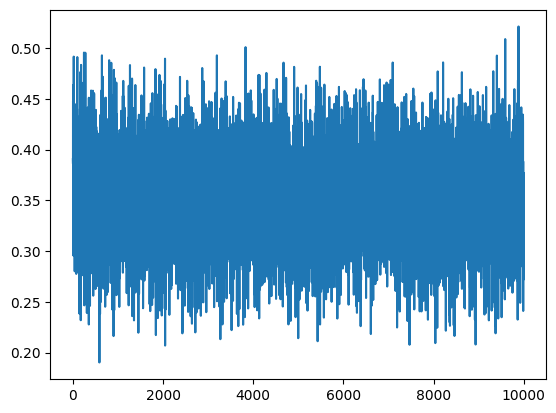

In [86]:
plt.plot(stepi, lossi)

上面的损失有时候会有一些跳变, 这是因为小批量数据本身会引入一定的噪声

In [87]:
sum(p.numel() for p in parameters)

11897

In [88]:
emb = C[Xtr] 
h = torch.tanh(emb.view(-1,30)@W1 + b1)
logits = h@W2 + b2
loss = F.cross_entropy(logits, Ytr)
print(loss.data)

tensor(2.2466)


In [89]:
# 在验证集上计算损失指标
emb = C[Xdev] 
h = torch.tanh(emb.view(-1,30)@W1 + b1)
logits = h@W2 + b2
loss = F.cross_entropy(logits, Ydev)
print(loss.data)

tensor(2.2602)


可以看到, 训练集和验证集上的损失差不多,说明没有出现过拟合(验证集没有在训练集中出现过)
+ 训练集: tensor(2.4443)
+ 验证集: tensor(2.4439)

但是损失还是比较大, (验证集和训练集效果都没有特别好),所以有点欠拟合

考虑使用更复杂的模型, 
1. 将上面隐藏层从100变成300, 参数量从3k→ 10k, 直接lr=0.1跑一次(1000轮), 再lr=0.01跑一次(1000轮)
    + 训练集: tensor(2.3588)
    + 验证集: tensor(2.3637)
    + 网络变大,就需要更长的step才能收敛
    + 开始调节lr,玄学炼丹了...
2. 模型参数扩大, 效果一般, 考虑这里可能存在瓶颈的地方是 **C这个嵌入矩阵只有2维,不能很好的表示模型**
   + 考虑增大C的嵌入维度
   + 多跑了几轮之后, 确实已经低于 2.3 了
   + 训练集: tensor(2.2466)
   + 验证集: tensor(2.2602)
   + 可以感受到,此时训练集和验证集已经开始出现差距了, 在走向过拟合的路上了, 所以此时网络肯定不是欠拟合了, 已经差不多ok了

In [90]:
# 经过验证集, 最终确定模型参数后, 再最后在测试集上测试
emb = C[Xte] 
h = torch.tanh(emb.view(-1,30)@W1 + b1)
logits = h@W2 + b2
loss = F.cross_entropy(logits, Yte)
print(loss.data)

tensor(2.2663)


确实没有很过拟合, 效果不错, 2.3以下~

之后,也可以继续优化:
+ 比如增加模型复杂度/增加数据,这里可以是增加输入的序列长度
+ 老师在课上的最优结果 是 2.17的损失值

# 可视化C(二维词嵌入)

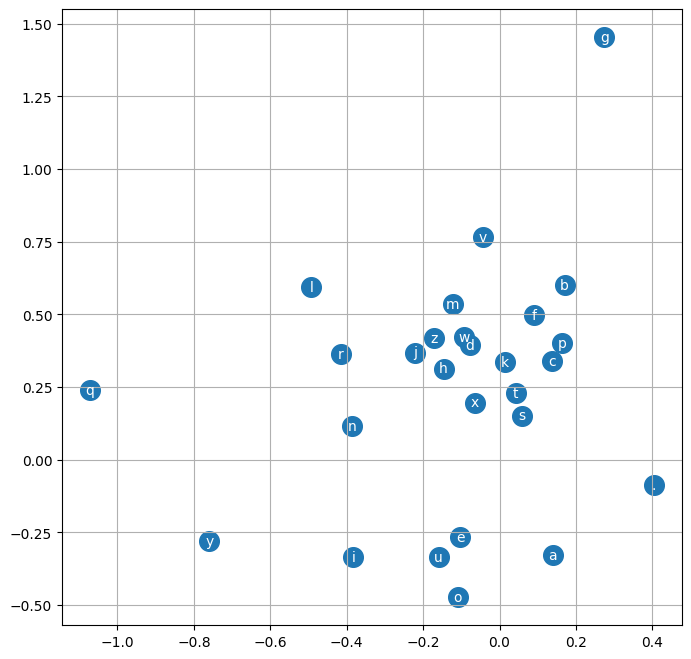

In [54]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    # C.shape = (27,2)
    plt.text(C[i,0].item(), C[i,1].item(),itos[i], ha = 'center', va = 'center', color = 'white')
plt.grid('minor')

这里可以看出, 其实模型已经学到了一些东西:
1. `a, e, i, o, u`元音字母聚集在一起, 说明神经网络在训练过程中, 认为这些是可以替换的, 具有相近的含义
2. `q`和`.`都是孤儿的离散点,

# 采样

In [91]:
g = torch.Generator().manual_seed(2147483647)
for i in range(20):
    out = []
    result = ''
    context = [0]*block_size 
    while True:
        emb = C[torch.tensor(context)] # (1, block_size, dim)
        h = torch.tanh(emb.view(-1,30)@W1 + b1)
        logits = h@W2 + b2
        p = F.softmax(logits, dim=1)
        ix = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item() 
        context = context[1:] + [ix]
        out.append(ix)
        if ix==0:
            break
    print(''.join(itos[i] for i in out))  

junide.
janasah.
pres.
aleina.
kaileltonia.
mathem.
dahnaa.
yanilenias.
deyainr.
imelysson.
evy.
arte.
farmanthyn.
demmerickys.
mah.
jaylyn.
reayaenacelynna.
din.
jamiin.
wyn.


上节课, 

单层线性层的结果:
```bash
最终的采样结果为: junide.
最终的采样结果为: janasah.
最终的采样结果为: p.
最终的采样结果为: cfay.
最终的采样结果为: a.
最终的采样结果为: nn.
最终的采样结果为: kohin.
最终的采样结果为: tolian.
最终的采样结果为: juwe.
最终的采样结果为: ksahnaauranilevias.
```

bigram的结果:

```bash
最终的采样结果为: junide.
最终的采样结果为: janasah.
最终的采样结果为: p.
最终的采样结果为: cony.    # cfay
最终的采样结果为: a.
最终的采样结果为: nn.
最终的采样结果为: kohin.
最终的采样结果为: tolian.
最终的采样结果为: juee.   # juwe
最终的采样结果为: ksahnaauranilevias.
```

看起来, 好像确实好一些~

# 其他

## torch.view()

[Tensor Views](https://docs.pytorch.org/docs/2.12/tensor_view.html)

In [31]:
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [32]:
a.view(3,3,2)

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [35]:
a.storage()
# a.untyped_storage()

 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

**存储部分其实就是数据本身，始终以一维形式存在**

In [36]:
b = torch.randn((3,3))
b.storage()

 0.14151038229465485
 -0.3052404224872589
 0.3999795913696289
 -0.2536049783229828
 0.48792070150375366
 -0.2613650858402252
 2.61295223236084
 -0.5991628170013428
 1.5737574100494385
[torch.storage.TypedStorage(dtype=torch.float32, device=cpu) of size 9]

`view()`是我们解释这个`storage()`的方式(包括： 存储偏移量(storage offset), 步幅(strides)，形状(shapes))，但是并不会对底层的存储进行改变(change)，复制(copy)，移动(move)。 

类似opencv里对mat的操作

[PyTorch internals](https://blog.ezyang.com/2019/05/pytorch-internals/)

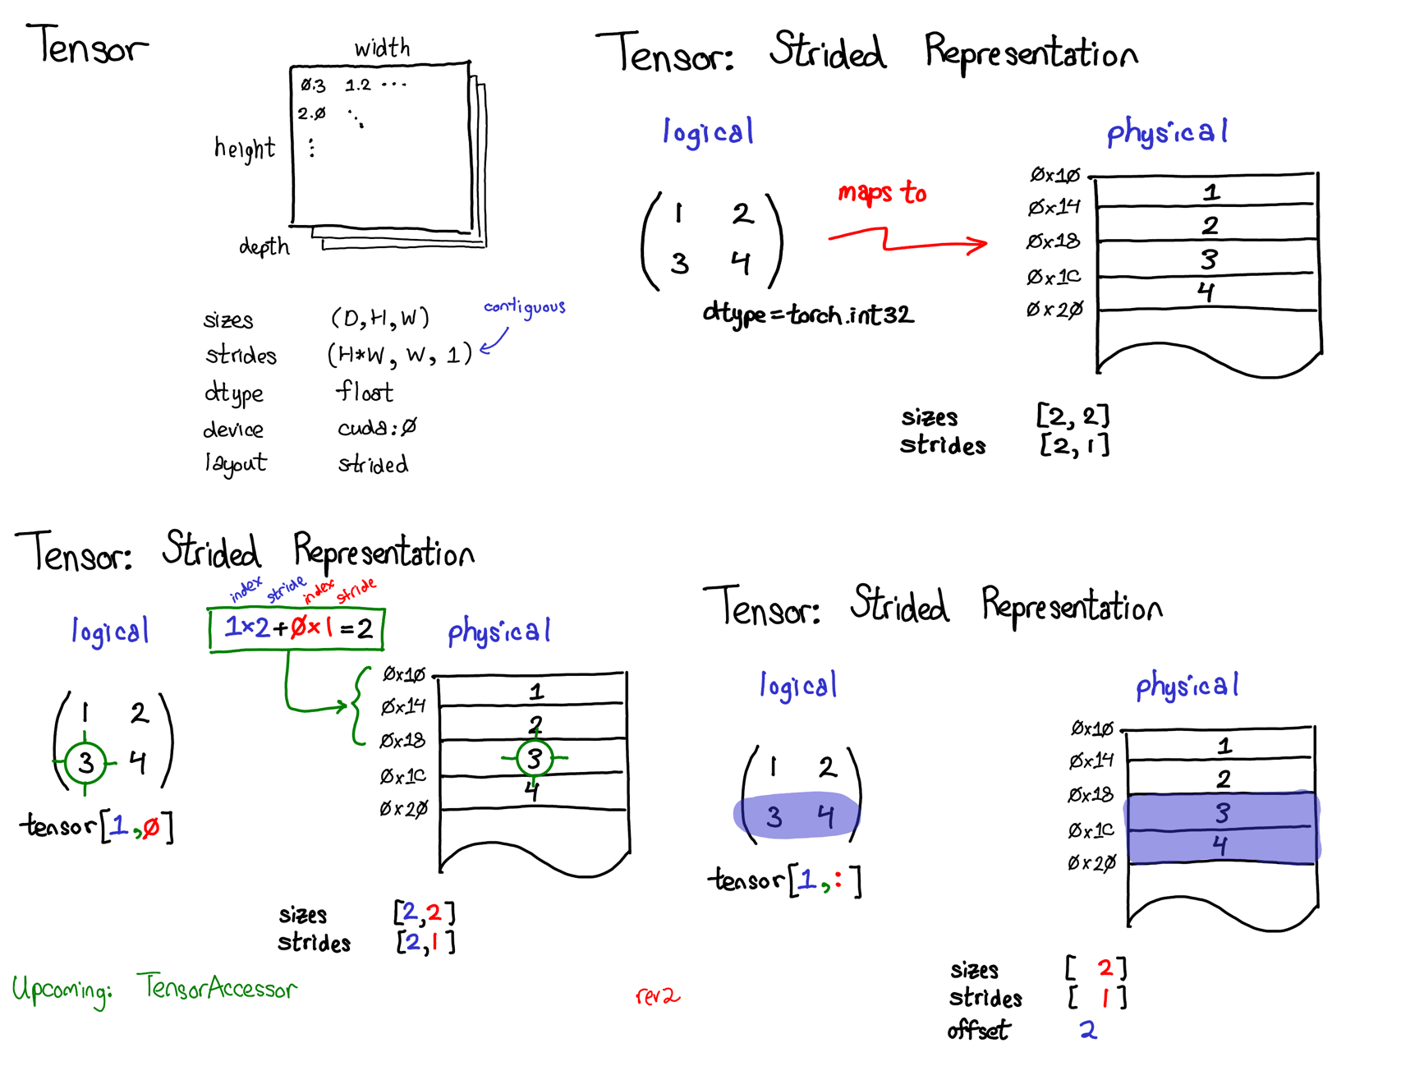

## 交叉熵损失函数

[torch.nn.functional.cross_entropy](https://docs.pytorch.org/docs/2.12/generated/torch.nn.functional.cross_entropy.html)

[Reference API -> torch.nn ->CrossEntropyLoss](https://docs.pytorch.org/docs/2.12/generated/torch.nn.CrossEntropyLoss.html#torch.nn.CrossEntropyLoss)

详见上面： **开始优化** 部分

```bash
F.cross_entropy(logits, Y)

V.S.

counts = logits.exp()
prob = counts/counts.sum(1,keepdim = True)
loss = - prob[torch.arange(32), Y].log().mean()

第一：实现效率
直接调用pytorch写好的函数，运行效率要远远优于后面的拆开写的

后面会创建很多中间张量（都会占用额外的运行存储空间）

而写好的函数 pytorch会进行很多聚合操作 并使用 fused kernels 来高效计算

除了前向的融合算子会高效计算，反向时，也会有数学和解析(analytically,  Mathematically)方面的优化

类似之前micrograd里实现的tanh，直接用exp实现，还是直接(1-t^2)

第二：数值稳定性

[ENH Adds _safe_softmax_last_dim for multiheadattention #63730](https://github.com/pytorch/pytorch/pull/63730/files#diff-1d3fef70dbc64e3e716d056f635ed159f3b3bb161930bc126317c5ff11d88957)
```

In [98]:
logits = torch.tensor([-100,-3,0,100])  # exp()的特性，当x很小时，y会接近0，这没问题； 当x很大时，y会无穷大
logits = torch.tensor([-100,-3,0,5])
logits = torch.tensor([-2,-3,0,5]) -2  # -2， +5这些偏移都ok， +100就不行了
#不加任何偏移时  tensor([9.0466e-04, 3.3281e-04, 6.6846e-03, 9.9208e-01])
counts = logits.exp()
prob = counts/counts.sum()
prob

tensor([0.0000e+00, 1.4013e-45, 3.7835e-44, 1.0000e+00])

由于`counts/counts.sum()`这个归一化操作的存在， 在`logits`上添加合适范围的偏移，不会对结果造成任何影响

由于负数可以接受，但是正数可能会在exp()的时候溢出，因此pytorch内部的做法是：
1. 先计算logits中的最大值，然后将logits整体减去这个最大值（作为偏移）

In [81]:
Y.shape

torch.Size([32])

`F.cross_entropy(input, target)` 对形状的约定是：

| 模式 | `input` 形状 | `target` 形状 | `target` 类型 |
|------|-------------|--------------|--------------|
| **类别索引模式** | `(N, C)` | `(N,)` | `Long` (int64) |
| **类别概率模式** | `(N, C)` | `(N, C)` | `Float` (float32) |

其中 `N` 是 batch size，`C` 是类别数。

In [100]:
logits = torch.tensor([-100,-3,0,100]).float()
Y2 = torch.tensor([0.0,2.0,2.0,1.0])
print(Y2.dtype, Y2.shape)
F.cross_entropy(logits, Y2)

torch.float32 torch.Size([4])


tensor(406.)